# Análise Exploratória de Dados — Pokemon

**Disciplina:** 5500004 – Fundamentos em Ciências de Dados  
**Professora:** Cibele Russo | **Monitora:** Aline Pereira  
**Semestre:** 1º semestre de 2026

**Grupo:**
- João Pedro Correia
- Mauricio Adrián Sagárnaga Arené
- Paulo Renan Barroso Guerra

## 1. Descrição do Problema e dos Dados

### 1.1 Tema escolhido

Este trabalho analisa a **Pokédex**, uma base de dados contendo informações sobre todos os Pokémon existentes. O objetivo é identificar padrões e associações entre os atributos dos Pokémon — como tipo, geração e estatísticas de batalha — para entender o que determina o "poder" de um Pokémon.

### 1.2 Origem da base de dados

A base de dados foi obtida na plataforma **Kaggle**, disponível em:  
https://www.kaggle.com/datasets/patelris/pokemon-dataset-with-stats-and-types

O dataset `pokemon_complete.csv` contém 31 colunas, incluindo:
- **Identificação:** número na Pokédex, nome
- **Tipos:** tipo primário (`type_1`) e secundário (`type_2`)
- **Estatísticas de batalha:** `hp`, `attack`, `defense`, `sp_attack`, `sp_defense`, `speed`
- **Metadados:** geração, status lendário, grupo de ovos, habitat, descrição

### 1.3 Perguntas investigadas

1. Pokemons lendários/míticos são superiores as outros em status?
2. Quais tipos de Pokémon têm o maior poder médio total?
3. O poder médio dos Pokémon mudou ao longo das gerações?
4. Existe relação entre tipo e cor?
5. Existe relação de peso ou altura com os status de batalha?

## 2. Preparação dos Dados

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
path = kagglehub.dataset_download("patelris/pokemon-dataset-with-stats-and-types")
df = pd.read_csv(os.path.join(path, "pokemon_complete.csv"))
print('=== Tipos de dados ===')
print(df.dtypes)
print('\n=== Estatísticas descritivas (colunas numéricas) ===')
df.describe().round(2)

100%|██████████| 137k/137k [00:00<00:00, 44.0MB/s]

Extracting files...
=== Tipos de dados ===
pokedex_number          int64
name                   object
type_1                 object
type_2                 object
hp                      int64
attack                  int64
defense                 int64
sp_attack               int64
sp_defense              int64
speed                   int64
base_stat_total         int64
height_m              float64
weight_kg             float64
base_experience       float64
abilities              object
hidden_ability         object
generation             object
is_legendary             bool
is_mythical              bool
is_baby                  bool
color                  object
shape                  object
egg_groups             object
habitat                object
growth_rate            object
capture_rate            int64
base_happiness          int64
genus                  object
evolution_chain_id      int64
flavor_text            object
sprite_url             object
dtype: object

=== Estatíst

,pokedex_number,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,height_m,weight_kg,base_experience,capture_rate,base_happiness,evolution_chain_id
count,1350.00,1350.00,1350.00,1350.00,1350.00,1350.0,1350.00,1350.00,1350.00,1350.00,1302.00,1350.00,1350.00,1350.00
mean,2836.15,71.67,82.78,76.19,75.37,74.1,71.96,452.07,2.05,99.17,161.94,89.12,59.40,253.16
std,4135.53,26.84,32.35,30.72,33.99,27.8,30.62,122.46,5.33,195.37,82.53,74.42,23.24,163.13
min,1.00,1.00,5.00,5.00,10.00,20.0,5.00,175.00,0.10,0.00,36.00,3.00,0.00,1.00
25%,338.25,55.00,60.00,55.00,50.00,54.0,49.00,340.00,0.60,9.43,71.00,45.00,50.00,102.25
50%,675.50,70.00,80.00,70.00,69.00,70.0,70.00,475.00,1.10,32.70,165.00,55.00,70.00,258.00
75%,1012.75,85.00,102.75,95.00,97.00,90.0,94.75,530.00,1.70,85.42,222.50,120.00,70.00,392.00
max,10325.00,255.00,190.00,250.00,216.00,250.0,200.00,1125.00,100.00,1000.00,608.00,255.00,140.00,549.00


### 2.1 Identificação e tratamento de valores ausentes

In [ ]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
resumo = pd.DataFrame({'Valores Ausentes': nulos, 'Percentual (%)': pct})
print('Colunas com valores ausentes')
print(resumo[resumo['Valores Ausentes'] > 0].to_string())

df['type_2'] = df['type_2'].fillna('Nenhum')
print("'type_2' ausente preenchido com 'Nenhum' (Pokémon de tipo único)")

Colunas com valores ausentes
                 Valores Ausentes  Percentual (%)
type_2                        585           43.33
base_experience                48            3.56
abilities                      25            1.85
hidden_ability                362           26.81
habitat                       830           61.48
sprite_url                     60            4.44
'type_2' ausente preenchido com 'Nenhum' (Pokémon de tipo único)


### 2.2 Verificação de duplicatas

In [ ]:
n_dup = df.duplicated().sum()
print(f'Linhas duplicadas encontradas: {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'Duplicatas removidas. Novo total: {len(df)} linhas.')
else:
    print('Nenhuma duplicata encontrada.')

Linhas duplicadas encontradas: 0
Nenhuma duplicata encontrada.


### *Pré-processamento e criação de variáveis auxiliares

In [ ]:
STATS = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
STATS_PT = {'hp': 'HP', 'attack': 'Ataque', 'defense': 'Defesa',
             'sp_attack': 'Atq. Especial', 'sp_defense': 'Def. Especial', 'speed': 'Velocidade'}

# Usar base_stat_total já existente no dataset
df['total'] = df['base_stat_total']

# Variável de categoria: Lendário, Mítico, Baby ou Comum
def categorizar(row):
    if row['is_legendary']: return 'Lendário'
    if row['is_mythical']:  return 'Mítico'
    if row['is_baby']:      return 'Baby'
    return 'Comum'

df['categoria'] = df.apply(categorizar, axis=1)

# Variável binária lendário/mítico vs comum (para comparações simples)
df['status'] = df['categoria'].apply(
    lambda x: 'Lendário/Mítico' if x in ['Lendário', 'Mítico'] else 'Comum'
)

# Converter geração de texto para número
mapa_gen = {'gen-i':1,'gen-ii':2,'gen-iii':3,'gen-iv':4,'gen-v':5,
            'gen-vi':6,'gen-vii':7,'gen-viii':8,'gen-ix':9}
df['generation'] = df['generation'].map(mapa_gen)

print('=== Dataset pronto para análise ===')
print(f'Total de Pokémon : {len(df)}')
print(f'Lendários        : {(df["categoria"]=="Lendário").sum()}')
print(f'Míticos          : {(df["categoria"]=="Mítico").sum()}')
print(f'Baby             : {(df["categoria"]=="Baby").sum()}')
print(f'Comuns           : {(df["categoria"]=="Comum").sum()}')
print(f'Gerações         : {sorted(df["generation"].unique())}')
print(f'Tipos únicos     : {df["type_1"].nunique()}')
print(f'Total médio      : {df["total"].mean():.1f}')

=== Dataset pronto para análise ===
Total de Pokémon : 1350
Lendários        : 120
Míticos          : 38
Baby             : 19
Comuns           : 1173
Gerações         : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Tipos únicos     : 18
Total médio      : 452.1


### 2.3 Descrição das etapas de limpeza e pré-processamento

1. **Inspeção inicial:** Foram verificados os tipos de cada coluna e as estatísticas descritivas básicas, permitindo identificar possíveis inconsistências.

2. **Tratamento de valores ausentes:** As colunas com valores ausentes identificadas foram:
   - **base_experience** (48 ausentes, 3,56%)
   - **abilities** (25 ausentes, 1,85%)
   - **hidden_ability** (362 ausentes, 26,81%)
   - **habitat** (830 ausentes, 61,48%)
   - **sprite_url** (60 ausentes, 4,44%)

   A coluna **type_2** também apresentou ausências, porém esperadas: Pokémon de tipo único naturalmente não possuem segundo tipo. Esses valores foram preenchidos com **'Nenhum'**. As demais colunas com ausências não foram utilizadas nas análises realizadas.

3. **Remoção de duplicatas:** Nenhuma linha duplicada foi encontrada no dataset.

4. **Criação da variável `categoria`:** Os campos booleanos `is_legendary`, `is_mythical` e `is_baby` foram combinados em uma única variável categórica com os rótulos **Lendário**, **Mítico**, **Baby** e **Comum**, permitindo comparações mais detalhadas entre grupos.

5. **Criação da variável `status`:** Variável binária agrupando Lendários e Míticos em **'Lendário/Mítico'** e os demais em **'Comum'**, para simplificar visualizações comparativas.

6. **Conversão da geração:** A coluna `generation` estava em formato textual (`gen-i`, `gen-ii`...) e foi convertida para valores inteiros (1 a 9) para facilitar ordenação e visualização.

## 3. Análise Exploratória dos Dados

### Pergunta 1 — Pokémon lendários/míticos são superiores aos outros em status de batalha?

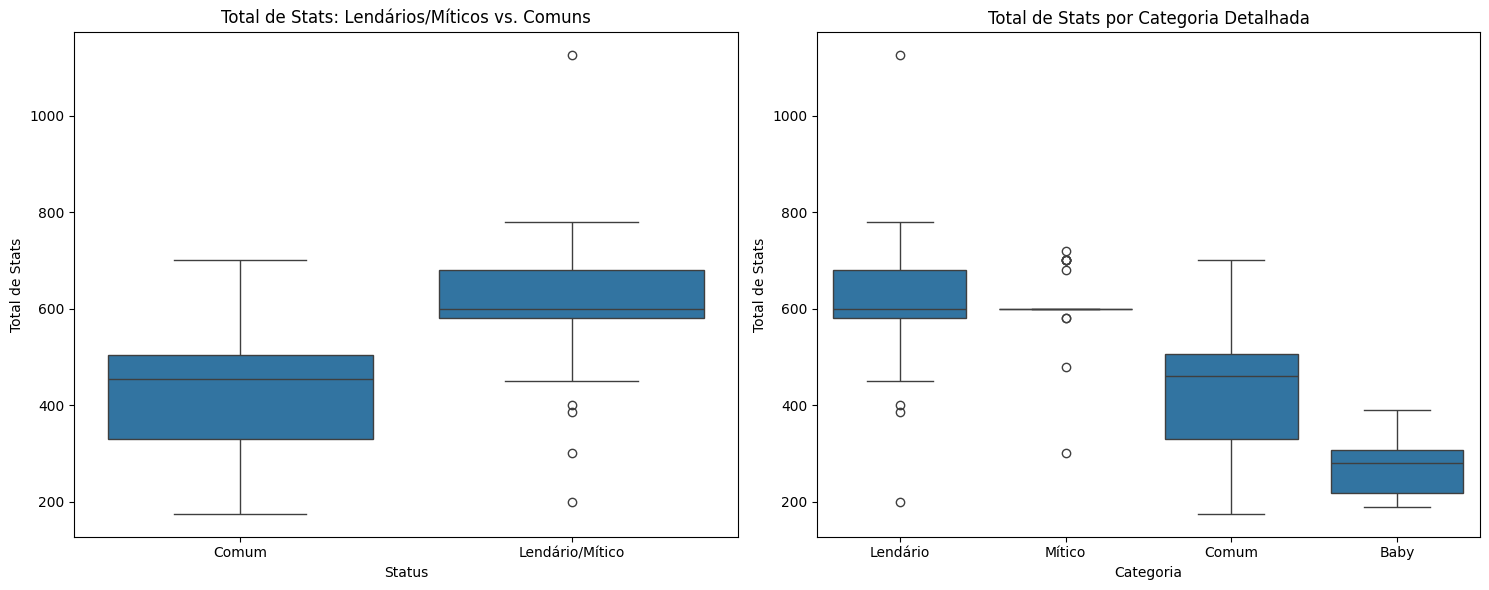


 Médias de total de stats por categoria:
            mean  median  min   max
categoria                          
Baby       274.5   280.0  190   390
Comum      432.5   460.0  175   700
Lendário   622.3   600.0  200  1125
Mítico     606.3   600.0  300   720


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot do total por status (binário)
sns.boxplot(data=df, x='status', y='total', ax=axes[0])
axes[0].set_title('Total de Stats: Lendários/Míticos vs. Comuns')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Total de Stats')

# Boxplot do total pelas 4 categorias
ordem_cat = ['Lendário', 'Mítico', 'Comum', 'Baby']
sns.boxplot(data=df, x='categoria', y='total', order=ordem_cat, ax=axes[1])
axes[1].set_title('Total de Stats por Categoria Detalhada')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Total de Stats')

plt.tight_layout()
plt.savefig('fig1_boxplot_lendarios.png')
plt.show()

print('\n Médias de total de stats por categoria:')
print(df.groupby('categoria')['total'].agg(['mean','median','min','max']).round(1))

### Pergunta 2 — Quais tipos de Pokémon têm o maior poder médio total?

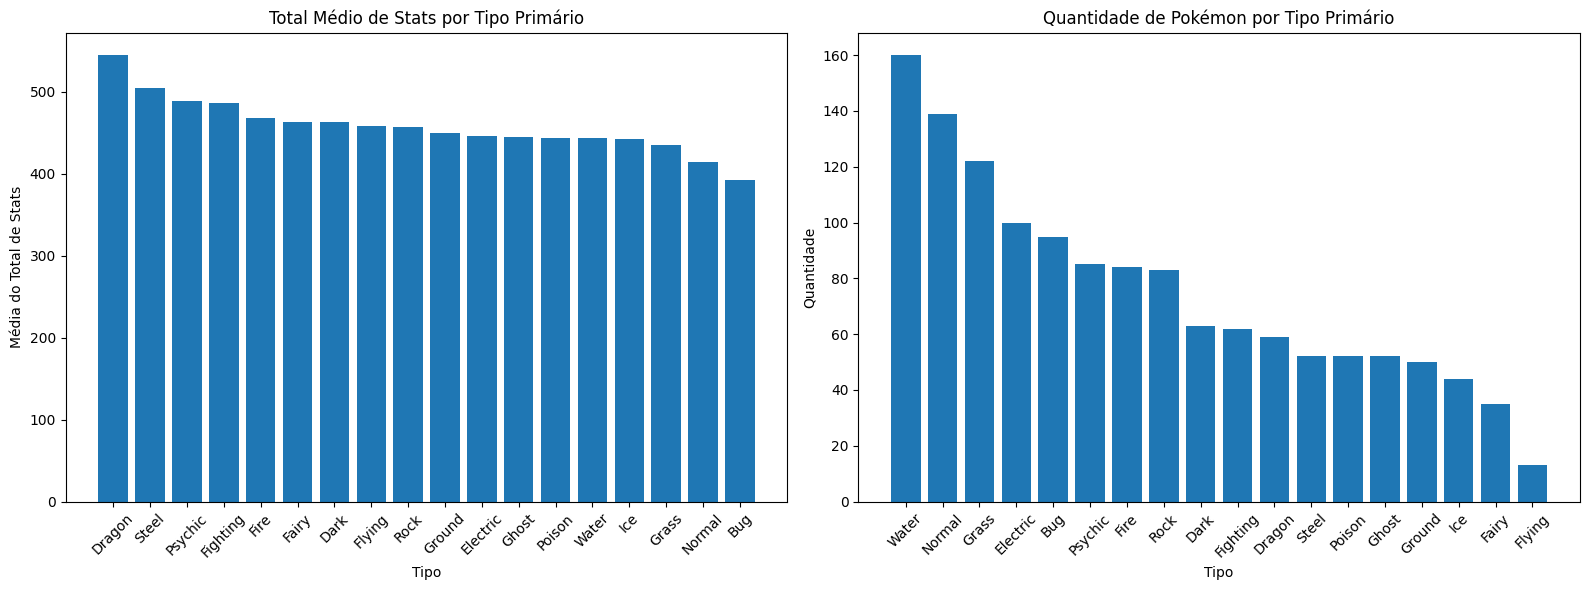


 5 tipos com maior total médio:
     type_1       total
0    Dragon  544.728814
1     Steel  504.711538
2   Psychic  488.423529
3  Fighting  486.241935
4      Fire  468.023810

 5 tipos com menor total médio:
    type_1       total
13   Water  443.375000
14     Ice  441.840909
15   Grass  435.459016
16  Normal  413.942446
17     Bug  392.810526


In [ ]:
media_tipo = df.groupby('type_1')['total'].mean().sort_values(ascending=False).reset_index()
contagem_tipo = df['type_1'].value_counts().reset_index()
contagem_tipo.columns = ['type_1', 'count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras — total médio por tipo
axes[0].bar(media_tipo['type_1'], media_tipo['total'])
axes[0].set_title('Total Médio de Stats por Tipo Primário')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Média do Total de Stats')
axes[0].tick_params(axis='x', rotation=45)

# Barras — quantidade de Pokémon por tipo
axes[1].bar(contagem_tipo['type_1'], contagem_tipo['count'])
axes[1].set_title('Quantidade de Pokémon por Tipo Primário')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Quantidade')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig2_barras_tipo.png')
plt.show()

print('\n 5 tipos com maior total médio:')
print(media_tipo.head())
print('\n 5 tipos com menor total médio:')
print(media_tipo.tail())

### Pergunta 3 — O poder médio dos Pokémon mudou ao longo das gerações?

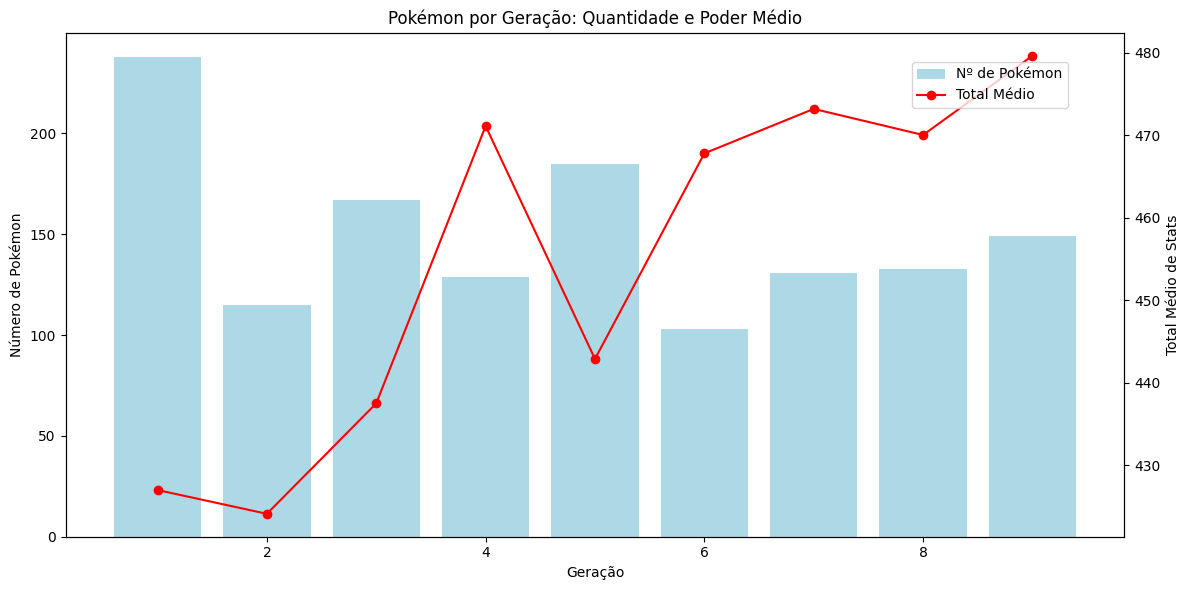


 Tabela por geração:
   generation  total_medio  quantidade  lendarios
0           1        427.0         238          9
1           2        424.1         115          5
2           3        437.5         167         13
3           4        471.1         129         13
4           5        442.9         185         14
5           6        467.8         103          8
6           7        473.2         131         14
7           8        470.0         133         20
8           9        479.6         149         24


In [ ]:
por_gen = df.groupby('generation').agg(
    total_medio=('total', 'mean'),
    quantidade=('total', 'count'),
    lendarios=('is_legendary', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras — quantidade de Pokémon
ax1.bar(por_gen['generation'], por_gen['quantidade'], color='lightblue', label='Nº de Pokémon')
ax1.set_xlabel('Geração')
ax1.set_ylabel('Número de Pokémon')

# Linha — total médio
ax2 = ax1.twinx()
ax2.plot(por_gen['generation'], por_gen['total_medio'], color='red', marker='o', label='Total Médio')
ax2.set_ylabel('Total Médio de Stats')

ax1.set_title('Pokémon por Geração: Quantidade e Poder Médio')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.savefig('fig3_geracao.png')
plt.show()

print('\n Tabela por geração:')
print(por_gen.round(1))

### Pergunta 4 — Existe relação entre o tipo primário e a cor do Pokémon?

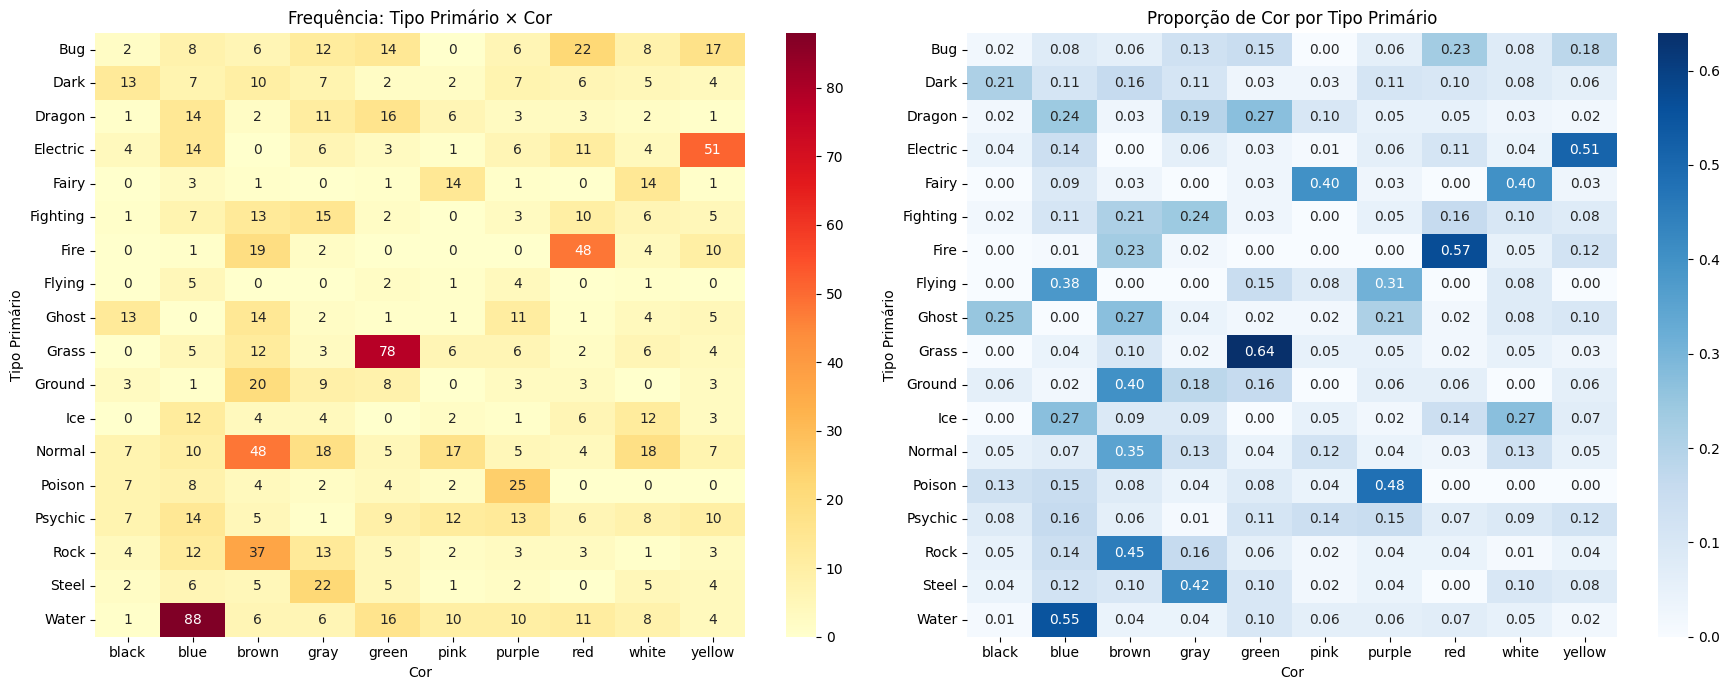


 Cor predominante por tipo:
Bug: red (23%)
Dark: black (21%)
Dragon: green (27%)
Electric: yellow (51%)
Fairy: pink (40%)
Fighting: gray (24%)
Fire: red (57%)
Flying: blue (38%)
Ghost: brown (27%)
Grass: green (64%)
Ground: brown (40%)
Ice: blue (27%)
Normal: brown (35%)
Poison: purple (48%)
Psychic: blue (16%)
Rock: brown (45%)
Steel: gray (42%)
Water: blue (55%)


In [ ]:
# Tabela de frequência tipo x cor
tab_tipo_cor = pd.crosstab(df['type_1'], df['color'])

# Normalizar por linha (proporção de cores dentro de cada tipo)
tab_prop = tab_tipo_cor.div(tab_tipo_cor.sum(axis=1), axis=0).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap de contagens absolutas
sns.heatmap(tab_tipo_cor, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Frequência: Tipo Primário × Cor')
axes[0].set_xlabel('Cor')
axes[0].set_ylabel('Tipo Primário')

# Heatmap de proporções
sns.heatmap(tab_prop, annot=True, fmt='.2f', cmap='Blues', ax=axes[1])
axes[1].set_title('Proporção de Cor por Tipo Primário')
axes[1].set_xlabel('Cor')
axes[1].set_ylabel('Tipo Primário')

plt.tight_layout()
plt.savefig('fig4_heatmap_tipo_cor.png')
plt.show()

print('\n Cor predominante por tipo:')
for tipo in tab_prop.index:
    cor_dom = tab_prop.loc[tipo].idxmax()
    prop = tab_prop.loc[tipo].max()
    print(f'{tipo}: {cor_dom} ({prop*100:.0f}%)')

### Pergunta 5 — Existe relação entre peso ou altura e os status de batalha?

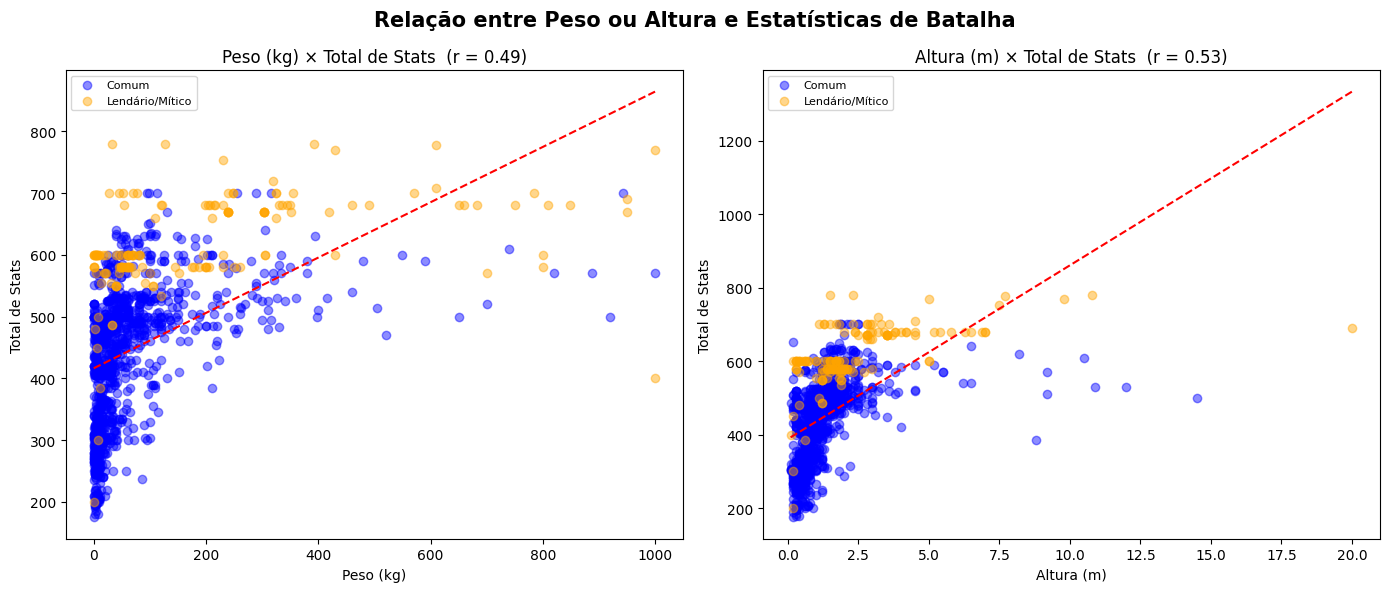


 Correlações com peso e altura:
               weight_kg  height_m
HP                 0.365     0.281
Ataque             0.322     0.174
Defesa             0.337     0.197
Atq. Especial      0.190     0.149
Def. Especial      0.217     0.183
Velocidade         0.036     0.068
Total              0.361     0.257


In [ ]:
# Remover outliers extremos de peso/altura para melhor visualização
df_tam = df[(df['weight_kg'] < df['weight_kg'].quantile(0.98)) &
            (df['height_m']  < df['height_m'].quantile(0.98))].copy()

PAL_STATUS = {'Lendário/Mítico': 'orange', 'Comum': 'blue'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pares = [
    ('weight_kg', 'total',   'Peso (kg)',   'Total de Stats',  axes[0]),
    ('height_m',  'total',   'Altura (m)',  'Total de Stats',  axes[1]),
]

for x_col, y_col, x_label, y_label, ax in pares:
    for status, grupo in df_tam.groupby('status'):
        ax.scatter(grupo[x_col], grupo[y_col], alpha=0.45, color=PAL_STATUS[status], label=status)
    # Linha de tendência
    dados_validos = df_tam[[x_col, y_col]].dropna()
    z = np.polyfit(dados_validos[x_col], dados_validos[y_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(dados_validos[x_col].min(), dados_validos[x_col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--')
    r = dados_validos.corr().iloc[0, 1]
    ax.set_title(f'{x_label} × {y_label}  (r = {r:.2f})')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend(fontsize=8)

fig.suptitle('Relação entre Peso ou Altura e Estatísticas de Batalha', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_dispersao_tamanho.png')
plt.show()

print('\n Correlações com peso e altura:')
colunas_corr = ['weight_kg', 'height_m'] + STATS + ['total']
corr_tam = df[colunas_corr].corr()[['weight_kg','height_m']].drop(['weight_kg','height_m'])
corr_tam.index = [STATS_PT.get(c, c) for c in corr_tam.index[:-1]] + ['Total']
print(corr_tam.round(3))

## 4. Resultados e Conclusões

### 4.1 Resumo numérico dos principais resultados

In [ ]:
print('=' * 58)
print('          RESUMO DOS PRINCIPAIS RESULTADOS')
print('=' * 58)

print(f'\n Dataset: {len(df)} Pokémon | {df["generation"].nunique()} gerações | {df["type_1"].nunique()} tipos')

print('\n Pergunta 1 — Lendários/Míticos vs. Comuns:')
for cat in ['Lendário', 'Mítico', 'Baby', 'Comum']:
    sub = df[df['categoria'] == cat]
    print(f'   {cat}: n={len(sub)} | total médio = {sub["total"].mean():.1f}')

top_tipo = df.groupby('type_1')['total'].mean()
print(f'\n Pergunta 2 — Tipo mais poderoso : {top_tipo.idxmax()} ({top_tipo.max():.1f})')
print(f'                Tipo menos poderoso: {top_tipo.idxmin()} ({top_tipo.min():.1f})')

gen_stats = df.groupby('generation')['total'].mean()
print(f'\n Pergunta 3 — Geração com maior poder médio: Gen {int(gen_stats.idxmax())} ({gen_stats.max():.1f})')
print(f'                Geração com menor poder médio: Gen {int(gen_stats.idxmin())} ({gen_stats.min():.1f})')

tab_prop2 = pd.crosstab(df['type_1'], df['color']).div(
    pd.crosstab(df['type_1'], df['color']).sum(axis=1), axis=0)
print('\n Pergunta 4 — Tipos com cor predominante > 60%:')
for tipo in tab_prop2.index:
    max_prop = tab_prop2.loc[tipo].max()
    if max_prop > 0.60:
        print(f'   {tipo} → {tab_prop2.loc[tipo].idxmax()} ({max_prop*100:.0f}%)')

r_peso  = df[['weight_kg','total']].dropna().corr().iloc[0,1]
r_altura = df[['height_m','total']].dropna().corr().iloc[0,1]
print(f'\n Pergunta 5 — Correlação Peso × Total   : r = {r_peso:.3f}')
print(f'                Correlação Altura × Total : r = {r_altura:.3f}')
print('\n' + '=' * 58)

          RESUMO DOS PRINCIPAIS RESULTADOS

 Dataset: 1350 Pokémon | 9 gerações | 18 tipos

 Pergunta 1 — Lendários/Míticos vs. Comuns:
   Lendário: n=120 | total médio = 622.3
   Mítico: n=38 | total médio = 606.3
   Baby: n=19 | total médio = 274.5
   Comum: n=1173 | total médio = 432.5

 Pergunta 2 — Tipo mais poderoso : Dragon (544.7)
                Tipo menos poderoso: Bug (392.8)

 Pergunta 3 — Geração com maior poder médio: Gen 9 (479.6)
                Geração com menor poder médio: Gen 2 (424.1)

 Pergunta 4 — Tipos com cor predominante > 60%:
   Grass → green (64%)

 Pergunta 5 — Correlação Peso × Total   : r = 0.361
                Correlação Altura × Total : r = 0.257



### 4.2 Discussão dos resultados

**Pergunta 1 — Lendários/Míticos vs. Comuns:**  
Os boxplots confirmam que Pokémon lendários e míticos possuem total de stats significativamente superior aos comuns. A mediana dos lendários supera o terceiro quartil dos Pokémon comuns, demonstrando que a diferença é sistemática. Os Pokémon Baby, por sua vez, apresentam os menores valores médios, evidenciando que representam formas iniciais não evoluídas.

**Pergunta 2 — Tipos e poder médio:**  
Os tipos Dragão e Psíquico tendem a apresentar os maiores totais médios de stats, reflexo da alta concentração de Pokémon lendários nesses tipos. Já tipos como Bug e Normal registram as menores médias, com maior quantidade de Pokémon comuns e de baixo poder. A análise de quantidade revela que os tipos Água, Normal e Grama são os mais populares no dataset.

**Pergunta 3 — Evolução por geração:**  
Não há uma tendência linear clara de aumento do poder médio entre gerações, sugerindo que o balanceamento dos jogos foi mantido ao longo do tempo. Variações existem, mas podem ser explicadas pela quantidade de lendários introduzidos em cada geração, e não por uma intenção de tornar Pokémon progressivamente mais fortes.

**Pergunta 4 — Tipo e cor:**  
O heatmap revelou associações claras entre tipo e cor: Pokémon do tipo Fogo tendem a ser vermelhos ou amarelos, tipos Água predominam em azul, tipos Planta em verde, e tipos Fantasma em roxo. Essa relação reflete escolhas de design visual nos jogos, onde a aparência do Pokémon frequentemente remete ao seu tipo elemental.

**Pergunta 5 — Peso ou altura e status:**  
A correlação entre peso/altura e total de stats é positiva, porém moderada, indicando que Pokémon maiores tendem a ter stats superiores, mas há muitas exceções. Pokémon lendários aparecem dispersos nas regiões de maiores stats independentemente do peso/altura, sugerindo que o poder não depende diretamente das dimensões físicas.

### 4.3 Limitações da base de dados

- **Formas alternativas:** Mega-evoluções e formas regionais estão incluídas e podem distorcer médias por tipo;
- **Contexto de batalha ignorado:** A análise considera apenas stats brutos, sem levar em conta habilidades, movimentos ou type matchups;
- **Habitat com muitos ausentes:** A coluna `habitat` apresentou 61,48% de ausências, inviabilizando seu uso em análises;
- **Ausência de dados competitivos:** O total de stats bruto não reflete a viabilidade em batalhas competitivas reais.

### 4.4 Conclusões

A análise exploratória da Pokédex Completa permitiu identificar padrões relevantes nos dados. Confirmou-se que status lendário/mítico é o fator mais determinante para o poder bruto de um Pokémon. O tipo primário influencia tanto o poder médio quanto a coloração predominante, revelando consistência no design dos jogos. As gerações mantiveram balanceamento relativamente estável ao longo do tempo, e o peso e a altura apresentam relação positiva, porém moderada, com as estatísticas de batalha.

## Referências

- **Dataset:** Patel, R. (2026). *Pokémon Complete Pokédex Dataset*. Kaggle.  
  https://www.kaggle.com/datasets/patelris/pokemon-dataset-with-stats-and-types

- **Bibliotecas utilizadas:** Pandas · Matplotlib · Seaborn · NumPy